# TRABALHO AV1 - SISTEMAS DE APOIO À TOMADA DE DECISÃO

## ALGORITMO: ÁRVORE DE DECISÃO (CRITÉRIO: ENTROPIA)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

In [2]:
# ==========================================
# CONFIGURAÇÕES DO PANDAS
# ==========================================

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### 1. CARREGAMENTO DOS DADOS

In [3]:
df = pd.read_csv('datatran2025.csv', sep=';', encoding='latin-1', low_memory=False)

In [4]:
df.head()

,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


### 2. PREPARAÇÃO E TRATAMENTO DOS DADOS (Atividade 4.1)

In [5]:
# Cria coluna de ocorrência de vítima (0 para sem vítimas e 1 para vítimas)
df['com_vitimas'] = df.apply(lambda row: 1 if (row['feridos'] > 0 or row['mortos'] > 0) else 0, axis=1)

# Seleciona colunas relevantes que servem para prever o acidente
colunas_preditoras = ['causa_acidente', 'tipo_acidente', 'fase_dia', 'condicao_metereologica']

# Filtra o dataset e removendo valores nulos
df_modelo = df[colunas_preditoras + ['com_vitimas']].dropna()

# Convertendo variáveis de texto em números (Categorização / One-Hot Encoding)
X = pd.get_dummies(df_modelo[colunas_preditoras], drop_first=True)
y = df_modelo['com_vitimas']

In [7]:
df_modelo.head()

,causa_acidente,tipo_acidente,fase_dia,condicao_metereologica,com_vitimas
0,Reação tardia ou ineficiente do condutor,Tombamento,Pleno dia,Céu Claro,1
1,Pista esburacada,Colisão frontal,Pleno dia,Céu Claro,1
2,Reação tardia ou ineficiente do condutor,Colisão traseira,Pleno dia,Sol,1
3,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Pleno dia,Céu Claro,1
4,Velocidade Incompatível,Colisão frontal,Pleno dia,Chuva,1


### 3. DIVISÃO EM TREINO E TESTE (Atividade 4.3)

In [8]:
# 70% dos dados para treinar o modelo e 30% para testar se ele aprendeu direito
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### 4. IMPLEMENTAÇÃO E TREINAMENTO DO ALGORITMO (Atividade 4.2 e 4.3)

In [9]:
# Utilizando a Entropia como critério de ganho de informação e limitando a profundidade para não travar
print("Treinando o modelo de Árvore de Decisão.")
modelo_arvore = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
modelo_arvore.fit(X_train, y_train)

Treinando o modelo de Árvore de Decisão.


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### 5. TESTE E AVALIAÇÃO DO MODELO (Atividade 4.4)

In [10]:
y_pred = modelo_arvore.predict(X_test)

print("\n=== MATRIZ DE CONFUSÃO ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== MÉTRICAS DE DESEMPENHO ===")
print(f"Acurácia Geral do Modelo: {accuracy_score(y_test, y_pred):.2%}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))


=== MATRIZ DE CONFUSÃO ===
[[  530  2818]
 [    9 18402]]

=== MÉTRICAS DE DESEMPENHO ===
Acurácia Geral do Modelo: 87.01%

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.98      0.16      0.27      3348
           1       0.87      1.00      0.93     18411

    accuracy                           0.87     21759
   macro avg       0.93      0.58      0.60     21759
weighted avg       0.89      0.87      0.83     21759



### 6. IDENTIFICAÇÃO DOS ATRIBUTOS MAIS RELEVANTES (Atividade 4.5)

In [11]:
importâncias = pd.DataFrame({
    'Atributo': X.columns,
    'Importancia': modelo_arvore.feature_importances_
}).sort_values(by='Importancia', ascending=False)

print("\n=== ATRIBUTOS MAIS RELEVANTES ===")
print(importâncias.head(5))


=== ATRIBUTOS MAIS RELEVANTES ===
                                           Atributo  Importancia
79                           tipo_acidente_Incêndio     0.669791
36  causa_acidente_Ingestão de álcool pelo condutor     0.188740
68          tipo_acidente_Atropelamento de Pedestre     0.060497
80       tipo_acidente_Queda de ocupante de veículo     0.057414
83                         tipo_acidente_Tombamento     0.010079


### 7. VISUALIZAÇÃO GRÁFICA DA ÁRVORE

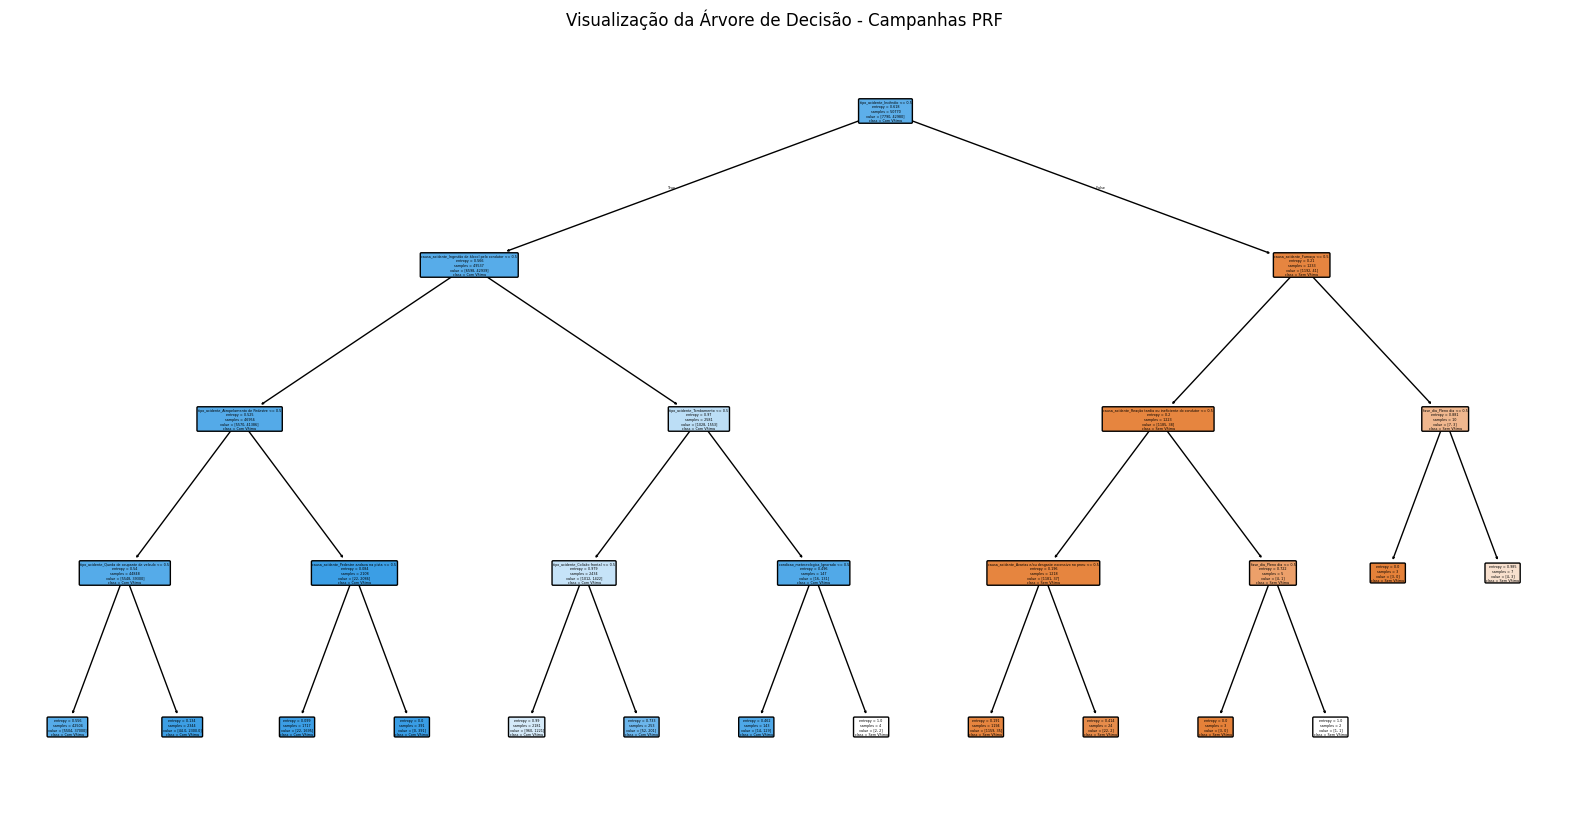

In [12]:
plt.figure(figsize=(20,10))
plot_tree(modelo_arvore, feature_names=X.columns, class_names=['Sem Vítima', 'Com Vítima'], filled=True, rounded=True)
plt.title("Visualização da Árvore de Decisão - Campanhas PRF")
plt.savefig('arvore_decisao.png', dpi=300)
plt.show()